# Batch Alignment

Batch trajectories must be time-aligned before unfolding for multi-way modelling. Three alignment strategies: simple (fixed count), phase-based, and indicator-variable (IV) alignment.

Batch DataFrame format: col 1 = batch ID (string), col 2 = `PHASE` (optional phase label).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyphi.batch as phibatch
import pyphi.plots as pp
from bokeh.io import output_notebook
output_notebook(hide_banner=True)
import pyphi.plots as _ppmod
_ppmod.output_file = lambda *a, **kw: None
%matplotlib inline


Will be using the NEOS server in the absence of IPOPT and GAMS


## Load Raw Batch Data

Columns: ['BATCH NUMBER', 'PHASE', 'Time (min)', 'DP_DRUM', 'INLET_AIR_TEMP', 'EXHAUST_AIR_TEMP', 'INLET_AIR', 'SPRAY_RATE', 'TOTAL_SPRAY_USED', 'INLET_AIR_HUMIDITY']
Batches: ['B211', 'B311', 'B411', 'B1205', 'B1805', 'B1810', 'B1905', 'B1910', 'B2010', 'B2110', 'B2210', 'B2510', 'B2705', 'B2710', 'B2805', 'B2810', 'B2910']


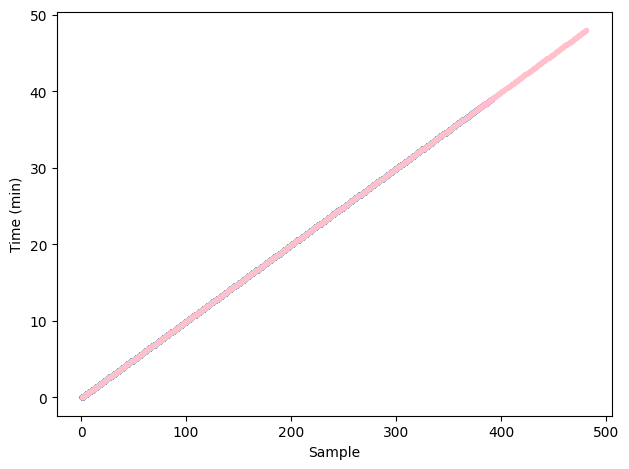

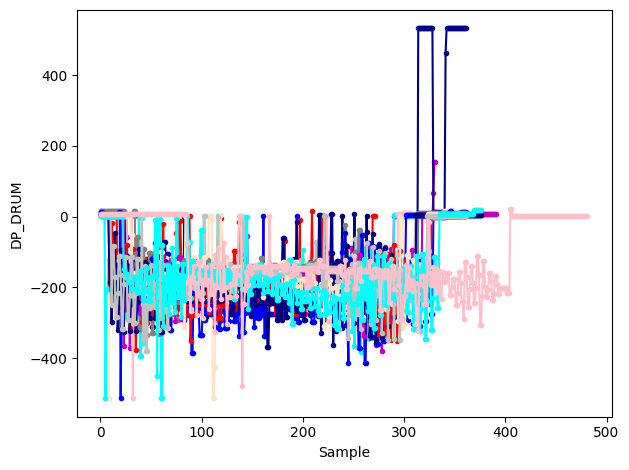

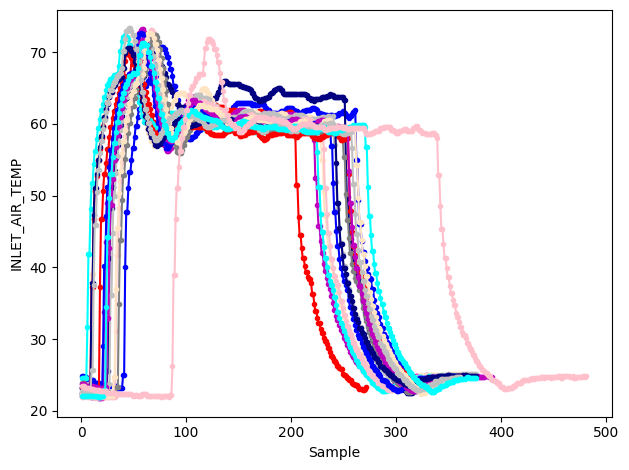

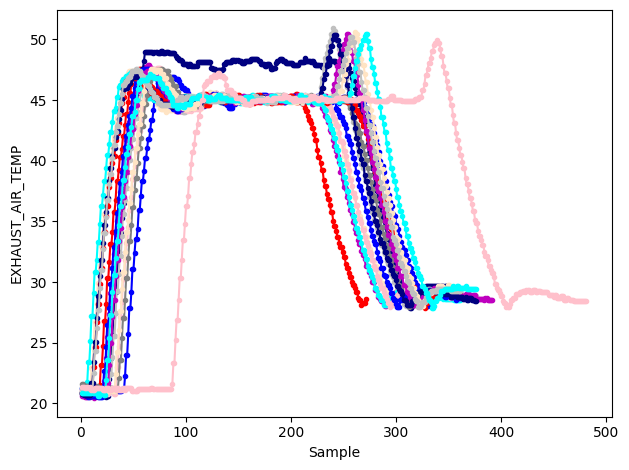

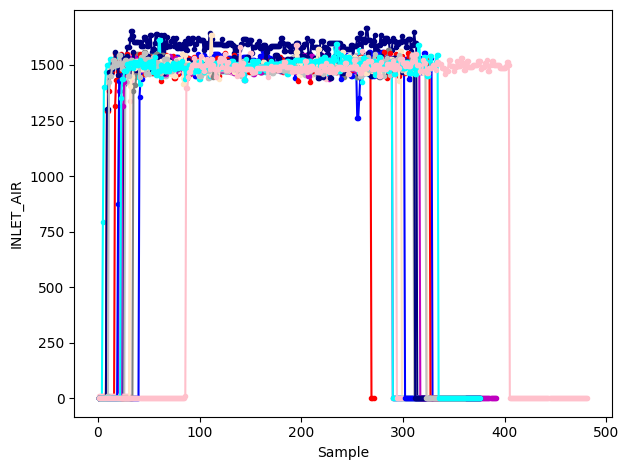

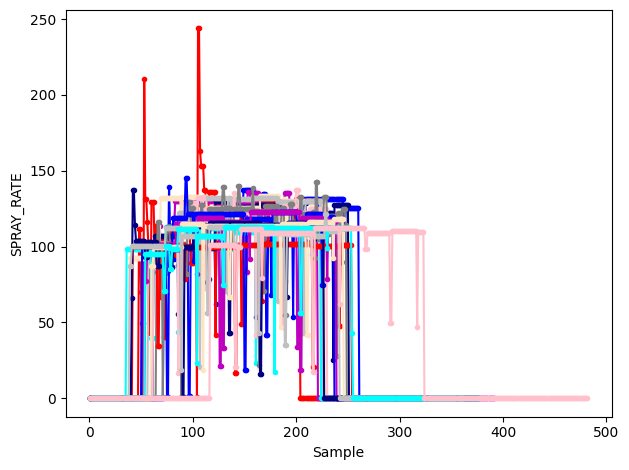

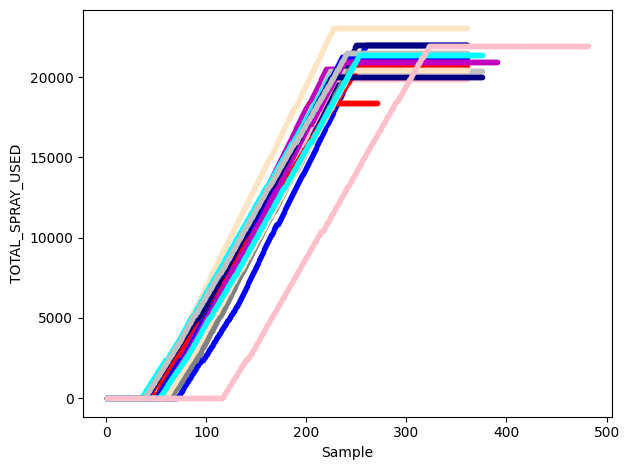

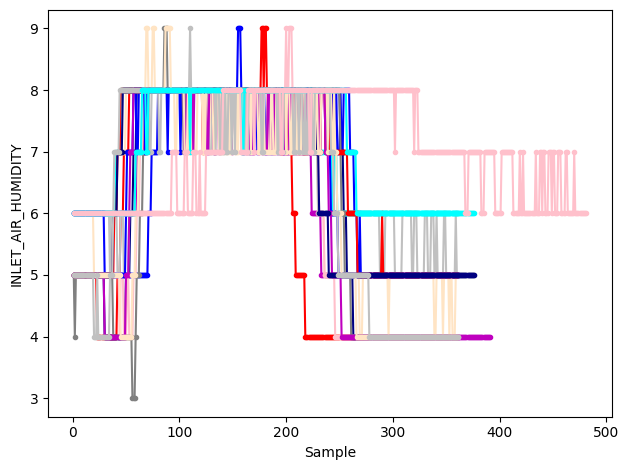

In [2]:
bdata = pd.read_excel('../data/Batch Film Coating.xlsx')
print('Columns:', bdata.columns.tolist())
print('Batches:', bdata.iloc[:, 0].unique().tolist())
phibatch.plot_var_all_batches(bdata)


## Simple Alignment

Resamples each batch to exactly N samples (interpolation). Ignores phase structure.

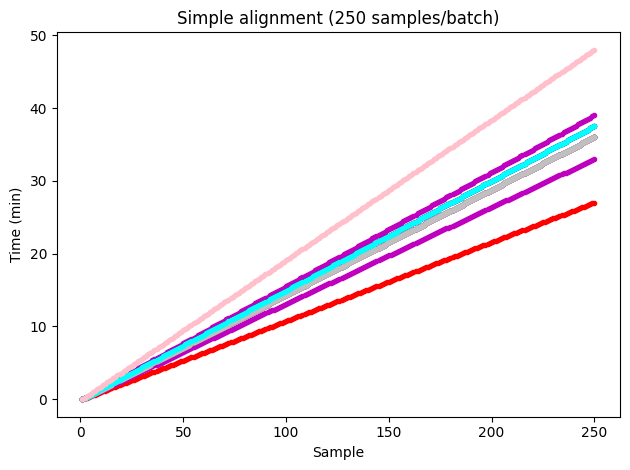

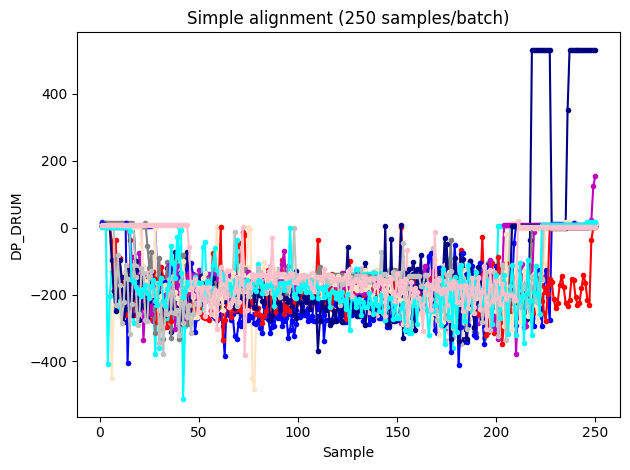

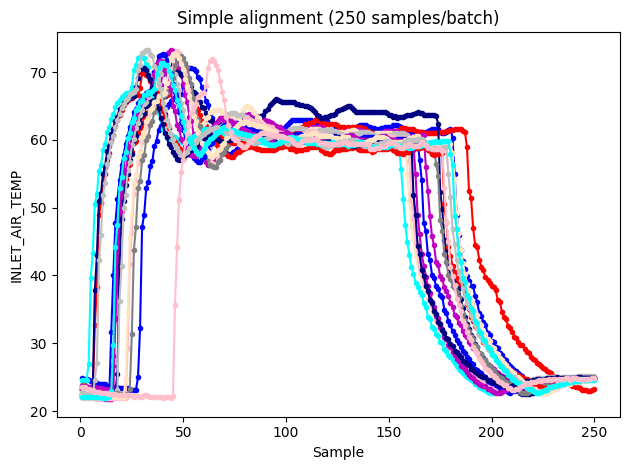

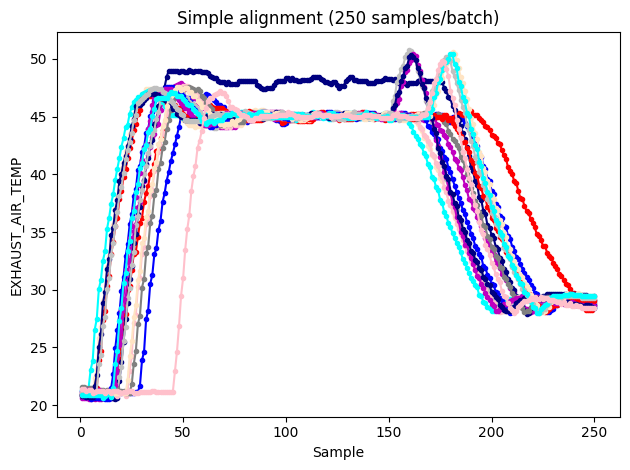

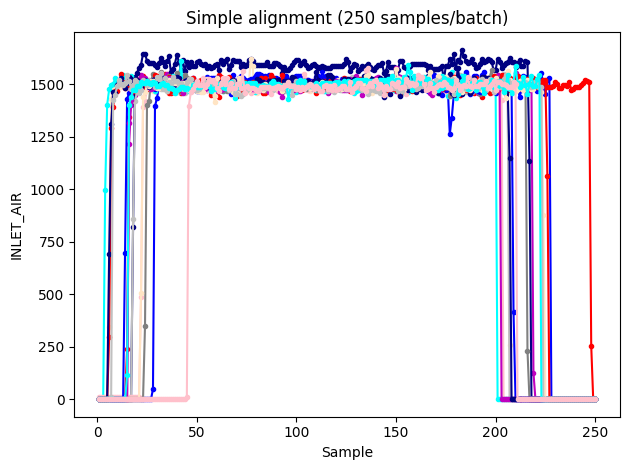

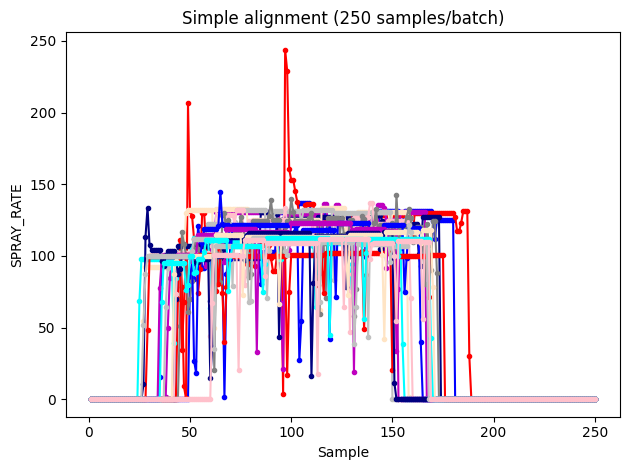

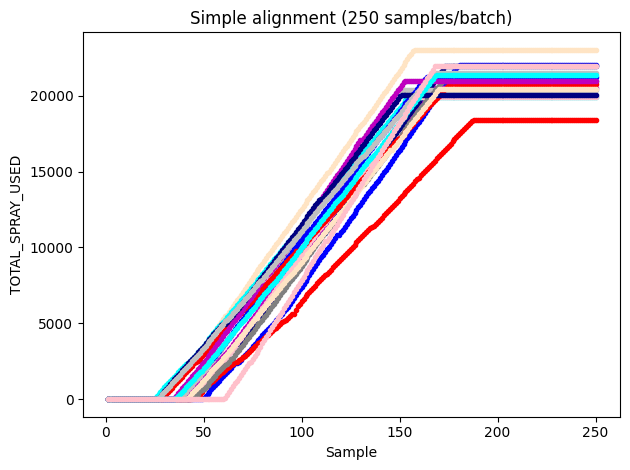

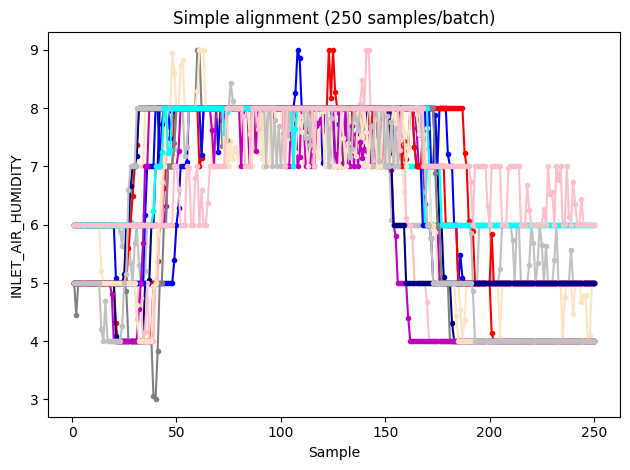

In [3]:
bdata_simple = phibatch.simple_align(bdata, 250)
phibatch.plot_var_all_batches(bdata_simple, plot_title='Simple alignment (250 samples/batch)')


## Phase Sampling Distribution

Check how many samples per phase each batch has before choosing `samples_per_phase`.

{'STARTUP': {'B211': 5,
  'B311': 22,
  'B411': 86,
  'B1205': 40,
  'B1805': 16,
  'B1810': 20,
  'B1905': 25,
  'B1910': 8,
  'B2010': 26,
  'B2110': 31,
  'B2210': 34,
  'B2510': 20,
  'B2705': 8,
  'B2710': 23,
  'B2805': 8,
  'B2810': 31,
  'B2910': 10},
 'HEATING': {'B211': 30,
  'B311': 31,
  'B411': 30,
  'B1205': 31,
  'B1805': 31,
  'B1810': 30,
  'B1905': 36,
  'B1910': 30,
  'B2010': 30,
  'B2110': 30,
  'B2210': 30,
  'B2510': 30,
  'B2705': 33,
  'B2710': 30,
  'B2805': 32,
  'B2810': 28,
  'B2910': 28},
 'SPRAYING': {'B211': 188,
  'B311': 201,
  'B411': 207,
  'B1205': 189,
  'B1805': 156,
  'B1810': 170,
  'B1905': 189,
  'B1910': 189,
  'B2010': 168,
  'B2110': 168,
  'B2210': 184,
  'B2510': 186,
  'B2705': 212,
  'B2710': 185,
  'B2805': 186,
  'B2810': 186,
  'B2910': 203},
 'DRYING': {'B211': 66,
  'B311': 80,
  'B411': 81,
  'B1205': 68,
  'B1805': 65,
  'B1810': 69,
  'B1905': 63,
  'B1910': 71,
  'B2010': 86,
  'B2110': 64,
  'B2210': 65,
  'B2510': 65,
  'B270

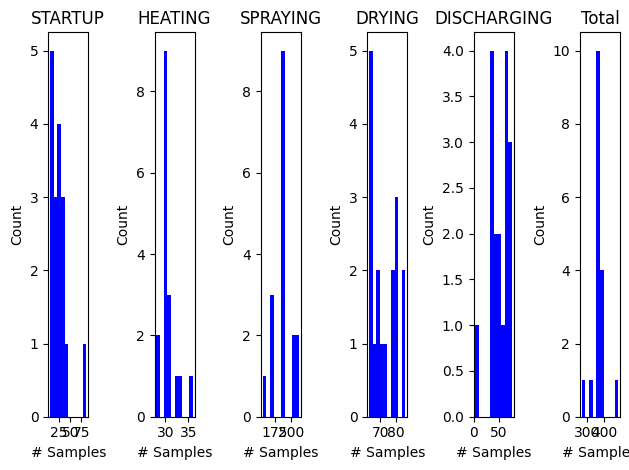

In [4]:
phibatch.phase_sampling_dist(bdata)

## Phase-Based Alignment

Aligns each phase independently to a fixed count. Preserves phase boundaries.

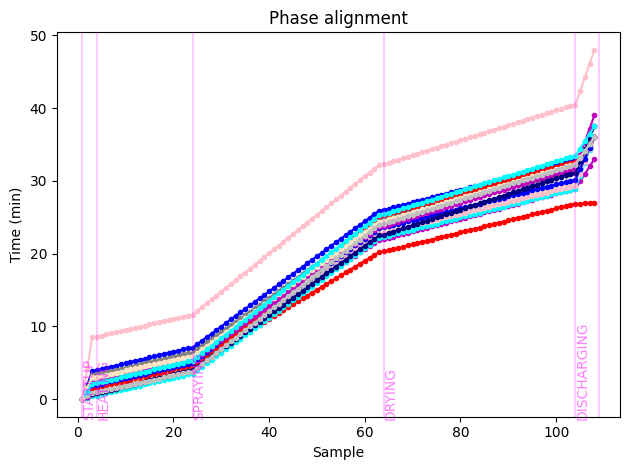

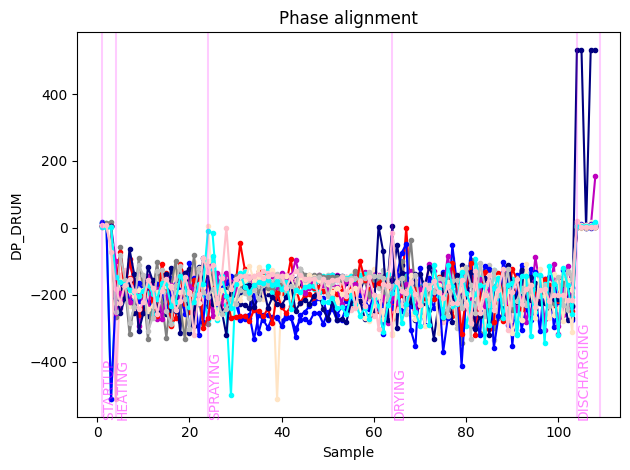

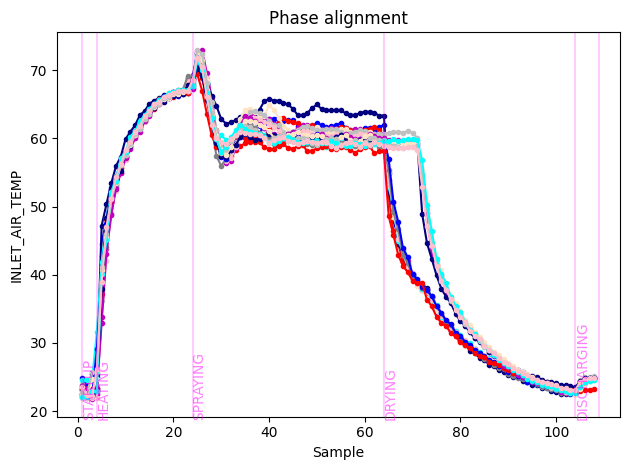

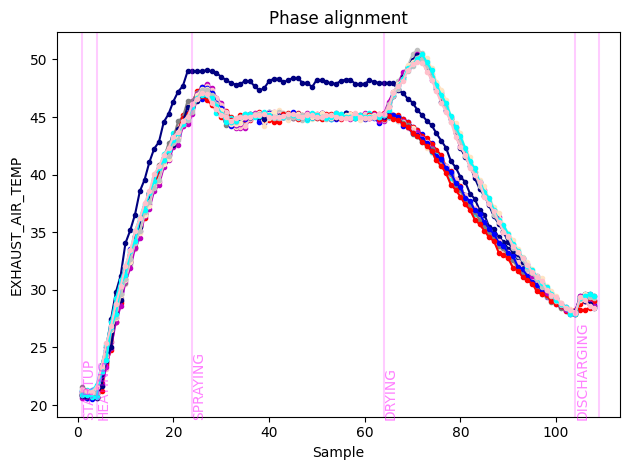

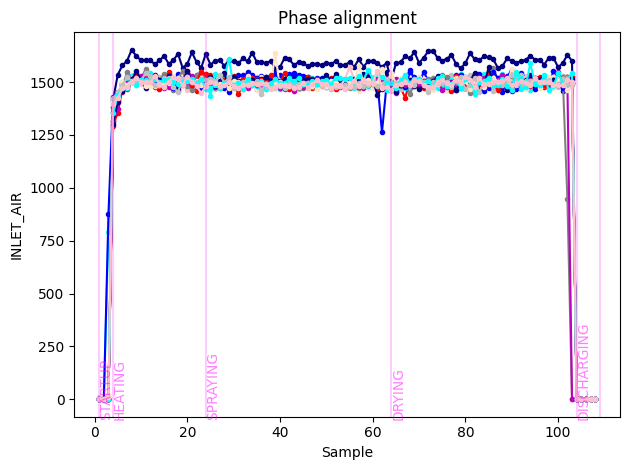

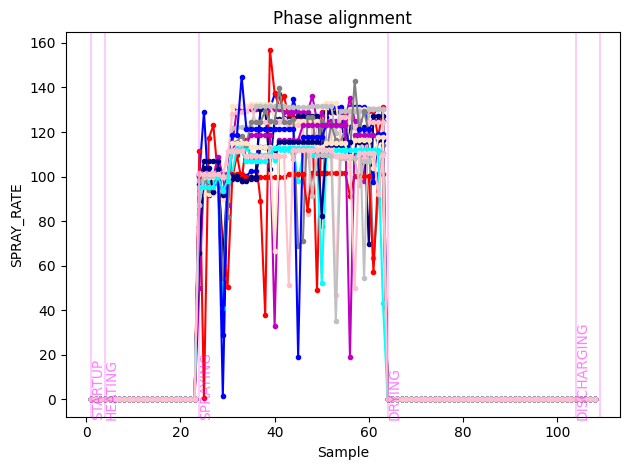

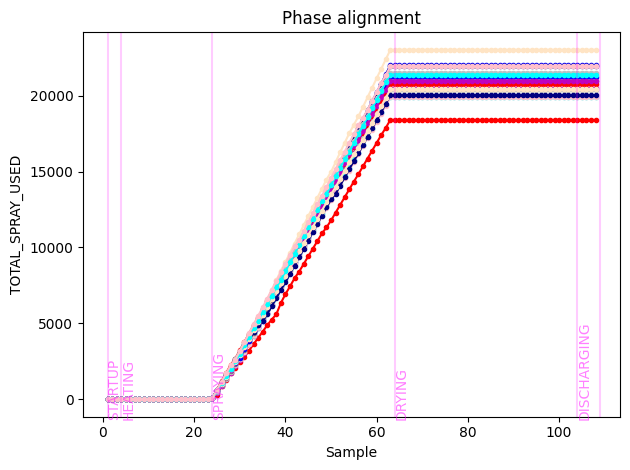

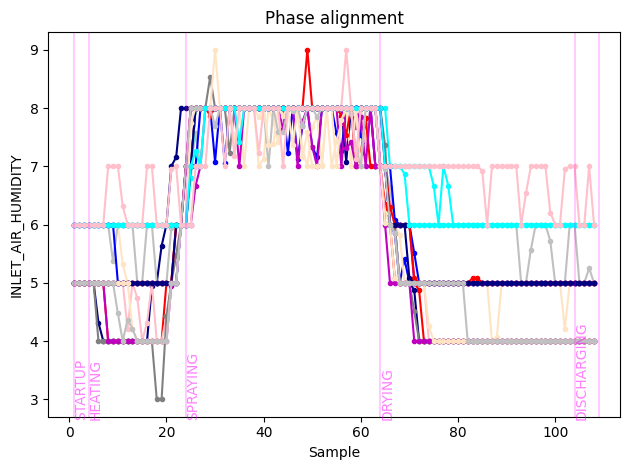

In [5]:
samples_per_phase = {
    'STARTUP': 3, 'HEATING': 20, 'SPRAYING': 40,
    'DRYING': 40, 'DISCHARGING': 5
}
bdata_phase = phibatch.phase_simple_align(bdata, samples_per_phase)
phibatch.plot_var_all_batches(bdata_phase,
                              plot_title='Phase alignment',
                              phase_samples=samples_per_phase)


## Indicator Variable (IV) Alignment

For a given phase, use a process variable trajectory (e.g. temperature) to determine alignment rather than sample count.

Syntax: replace the sample count for a phase with `[variable_name, n_samples, end_value]`.

Indicator variable INLET_AIR_TEMP for batch B211 is not monotinic
this is not ideal, maybe rethink your IV
trying to remove non-monotonic samples
Indicator variable INLET_AIR_TEMP for batch B311 is not monotinic
this is not ideal, maybe rethink your IV
trying to remove non-monotonic samples
Indicator variable INLET_AIR_TEMP for batch B411 is not monotinic
this is not ideal, maybe rethink your IV
trying to remove non-monotonic samples
Indicator variable INLET_AIR_TEMP for batch B1205 is not monotinic
this is not ideal, maybe rethink your IV
trying to remove non-monotonic samples
Indicator variable INLET_AIR_TEMP for batch B1805 is not monotinic
this is not ideal, maybe rethink your IV
trying to remove non-monotonic samples
Indicator variable INLET_AIR_TEMP for batch B1810 is not monotinic
this is not ideal, maybe rethink your IV
trying to remove non-monotonic samples
Indicator variable INLET_AIR_TEMP for batch B1905 is not monotinic
this is not ideal, maybe rethink your IV
trying to rem

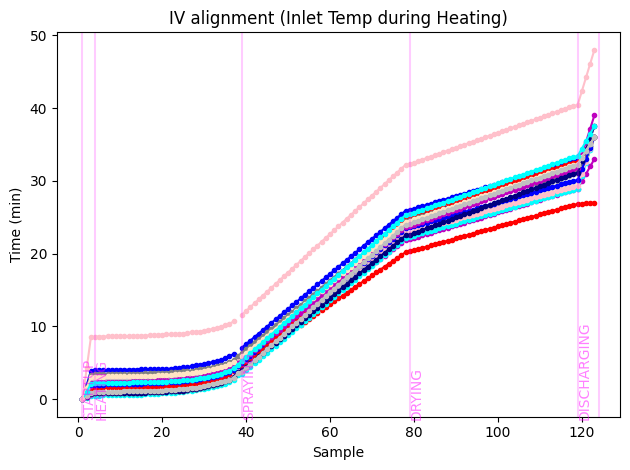

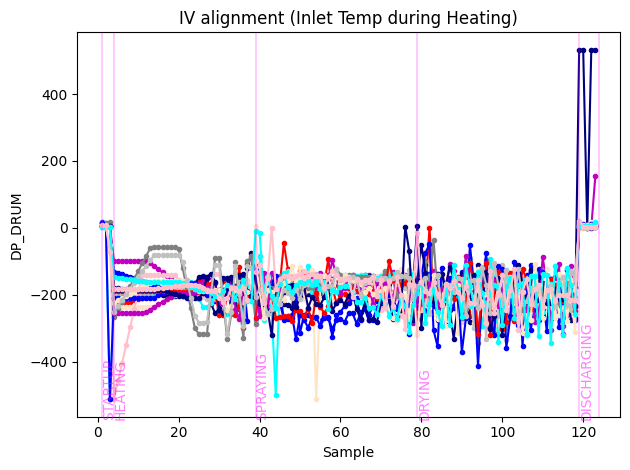

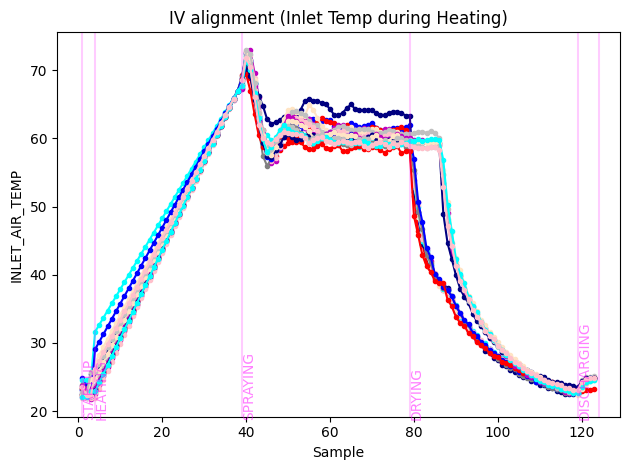

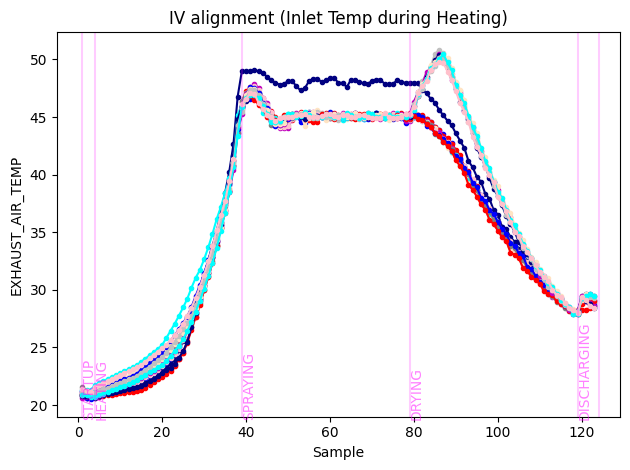

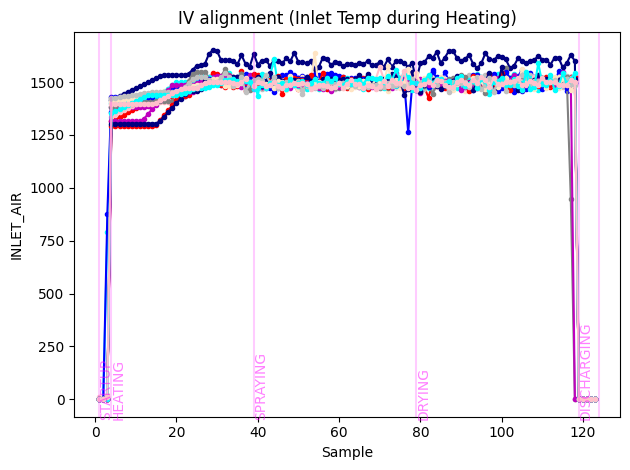

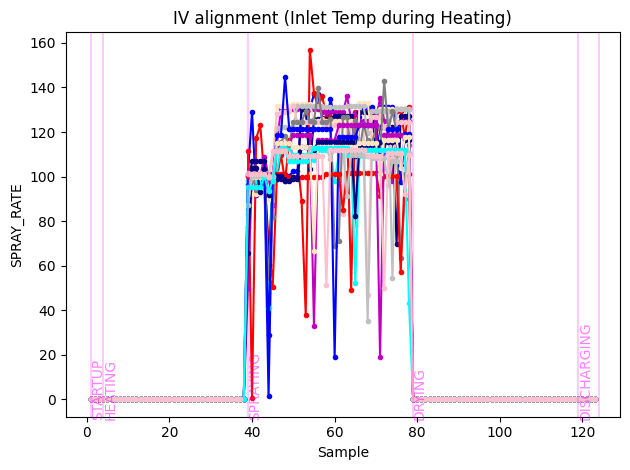

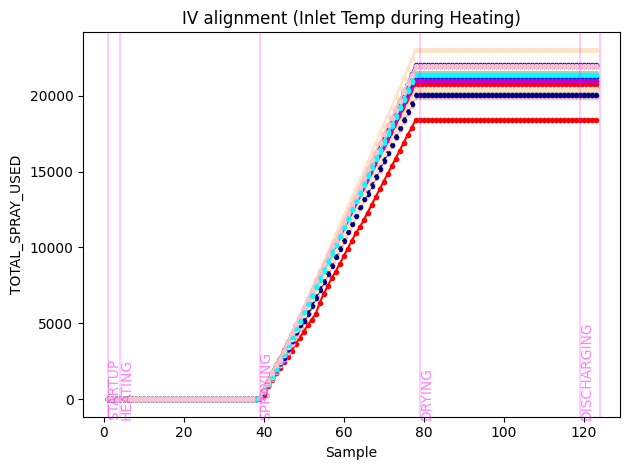

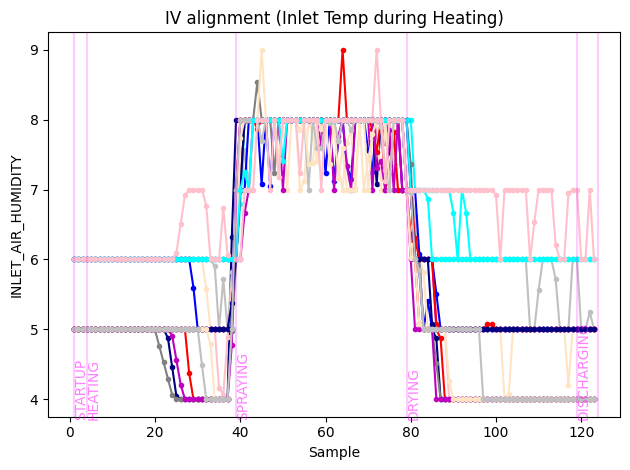

In [6]:
samples_iv = {
    'STARTUP': 3,
    'HEATING': ['INLET_AIR_TEMP', 35, 67],
    'SPRAYING': 40,
    'DRYING': 40,
    'DISCHARGING': 5
}
bdata_iv = phibatch.phase_iv_align(bdata, samples_iv)
phibatch.plot_var_all_batches(bdata_iv,
                              plot_title='IV alignment (Inlet Temp during Heating)',
                              phase_samples=samples_iv)


## Plot Individual Batches

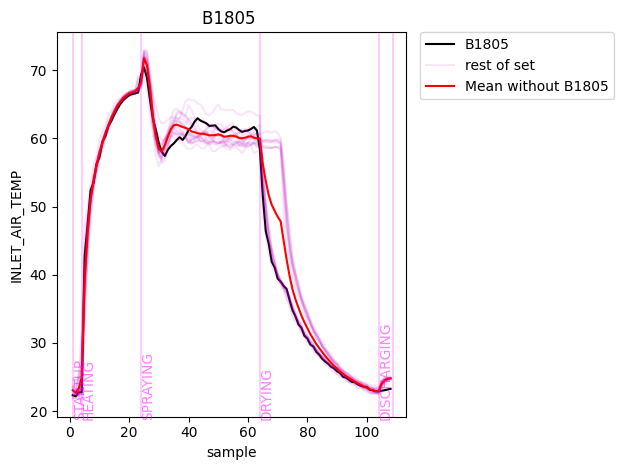

In [7]:
phibatch.plot_batch(bdata_phase, which_batch='B1805', which_var='INLET_AIR_TEMP',
                   include_set=True, include_mean_exc=True,
                   phase_samples=samples_per_phase)
